# Week 5 — NLP & Sentiment Analysis
**IT Simplera Institute — AI/ML Pre-Internship Program**

**Name:** Komal
**Roll No:** AIMLB01-1730
**Task:** Natural Language Processing & Sentiment Analysis Dashboard
**Dataset:** Amazon customer reviews (review text + sentiment label)

This notebook covers text cleaning, word clouds, vectorization, model training, evaluation, and saving the best model for the Streamlit dashboard in Part 2.

In [1]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import joblib

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

pd.set_option("display.max_colwidth", 120)


## 1. Load the Dataset & Inspect Class Distribution

The dataset used here is a set of real Amazon product reviews (Alexa devices) with a `verified_reviews` text column and a `feedback` column (1 = positive, 0 = negative), which is used as the sentiment label.

In [2]:
df = pd.read_csv("../data/amazon_reviews.csv")
print("Shape:", df.shape)
df.head()


Shape: (3150, 5)


,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer a question correctly but Alexa says you got it wrong and answers the ...",1
3,5,31-Jul-18,Charcoal Fabric,"I have had a lot of fun with this thing. My 4 yr old learns about dinosaurs, i control the lights and play games lik...",1
4,5,31-Jul-18,Charcoal Fabric,Music,1


In [3]:
df.info()
print("\nMissing values:\n", df.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   rating            3150 non-null   int64
 1   date              3150 non-null   str  
 2   variation         3150 non-null   str  
 3   verified_reviews  3149 non-null   str  
 4   feedback          3150 non-null   int64
dtypes: int64(2), str(3)
memory usage: 599.7 KB

Missing values:
 rating              0
date                0
variation           0
verified_reviews    1
feedback            0
dtype: int64


In [4]:
# Drop the single row with a missing review, keep only what we need
df = df.dropna(subset=["verified_reviews"]).reset_index(drop=True)
df = df[["verified_reviews", "feedback"]].rename(columns={"verified_reviews": "review", "feedback": "sentiment"})
df["sentiment_label"] = df["sentiment"].map({1: "positive", 0: "negative"})
df.head()


,review,sentiment,sentiment_label
0,Love my Echo!,1,positive
1,Loved it!,1,positive
2,"Sometimes while playing a game, you can answer a question correctly but Alexa says you got it wrong and answers the ...",1,positive
3,"I have had a lot of fun with this thing. My 4 yr old learns about dinosaurs, i control the lights and play games lik...",1,positive
4,Music,1,positive


sentiment_label
positive    2893
negative     256
Name: count, dtype: int64

Class balance (%):
sentiment_label
positive    91.87
negative     8.13
Name: count, dtype: float64


/tmp/ipykernel_631/875058221.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="sentiment_label", palette=["#2ecc71", "#e74c3c"])


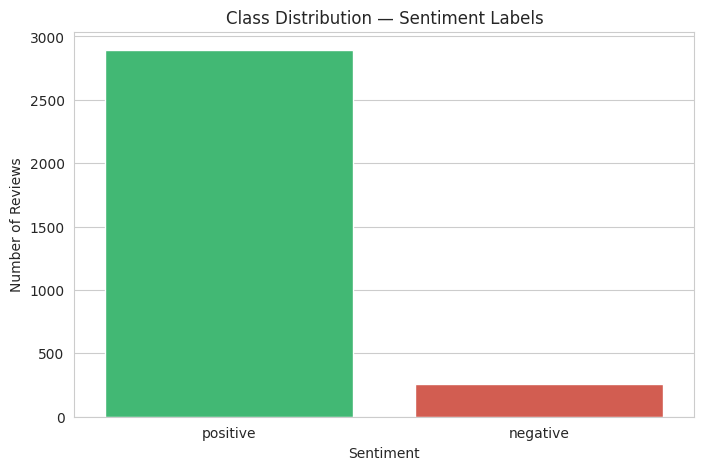

In [5]:
class_counts = df["sentiment_label"].value_counts()
print(class_counts)
print("\nClass balance (%):")
print((class_counts / len(df) * 100).round(2))

plt.figure()
sns.countplot(data=df, x="sentiment_label", palette=["#2ecc71", "#e74c3c"])
plt.title("Class Distribution — Sentiment Labels")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.savefig("../model/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


**Observation:** The dataset is heavily imbalanced — the large majority of reviews are positive, with only a small share negative. This is handled later by using `class_weight="balanced"` in the models rather than discarding data, since the dataset is fairly small once split.

## 2. Text Cleaning

Steps applied to each review:
- Lowercase everything
- Remove HTML tags, URLs, and non-alphabetic characters
- Remove extra whitespace
- Remove stopwords (common words that carry no sentiment meaning, e.g. "the", "is", "and")
- Drop very short tokens (length 1)

In [6]:
stop_words = set(ENGLISH_STOP_WORDS)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)                 # HTML tags
    text = re.sub(r"http\S+|www\.\S+", " ", text)      # URLs
    text = re.sub(r"[^a-z\s]", " ", text)               # keep letters only
    text = re.sub(r"\s+", " ", text).strip()
    tokens = [w for w in text.split() if w not in stop_words and len(w) > 1]
    return " ".join(tokens)

df["clean_review"] = df["review"].apply(clean_text)
df[["review", "clean_review"]].head(8)


,review,clean_review
0,Love my Echo!,love echo
1,Loved it!,loved
2,"Sometimes while playing a game, you can answer a question correctly but Alexa says you got it wrong and answers the ...",playing game answer question correctly alexa says got wrong answers like able turn lights away home
3,"I have had a lot of fun with this thing. My 4 yr old learns about dinosaurs, i control the lights and play games lik...",lot fun thing yr old learns dinosaurs control lights play games like categories nice sound playing music
4,Music,music
5,"I received the echo as a gift. I needed another Bluetooth or something to play music easily accessible, and found th...",received echo gift needed bluetooth play music easily accessible smart speaker wait
6,"Without having a cellphone, I cannot use many of her features. I have an iPad but do not see that of any use. It IS...",having cellphone use features ipad use great alarm deaf hear alarm bedroom living room reason fun ask random questio...
7,I think this is the 5th one I've purchased. I'm working on getting one in every room of my house. I really like what...,think th ve purchased working getting room house really like features offer specifily playing music echos controllin...


In [7]:
# Drop any reviews that became empty after cleaning
df = df[df["clean_review"].str.len() > 0].reset_index(drop=True)
print("Final dataset size:", df.shape)


Final dataset size: (3059, 4)


## 3. Word Clouds — Positive vs Negative Reviews

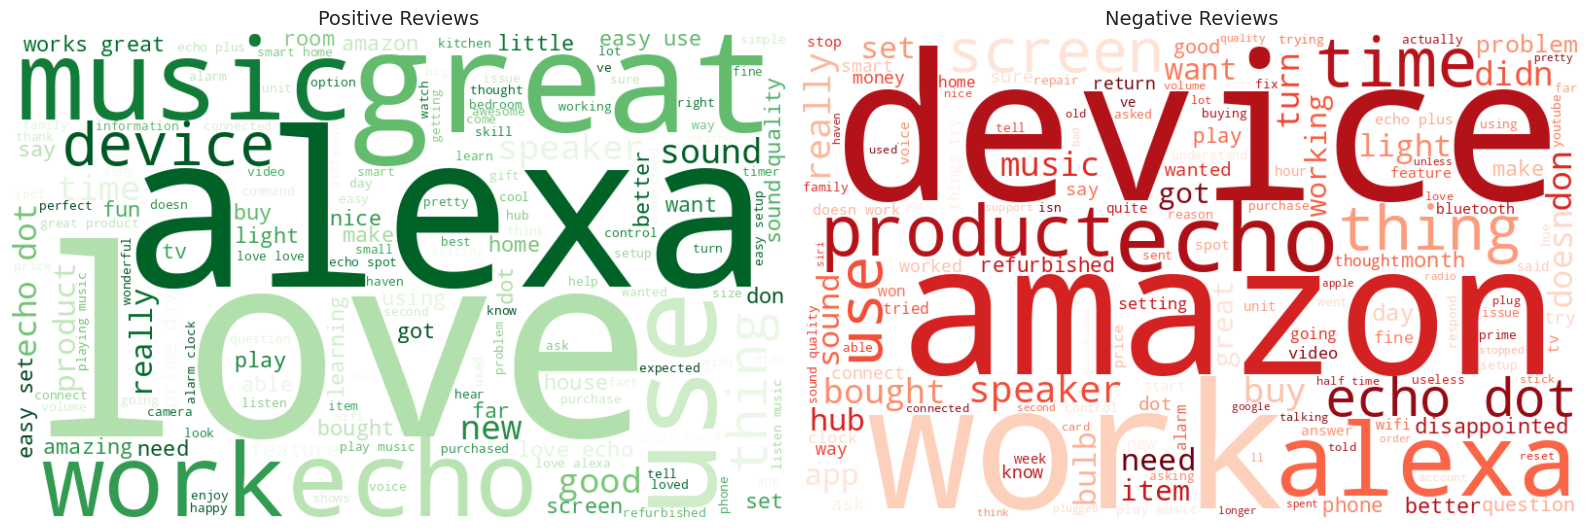

In [8]:
positive_text = " ".join(df.loc[df["sentiment"] == 1, "clean_review"])
negative_text = " ".join(df.loc[df["sentiment"] == 0, "clean_review"])

wc_positive = WordCloud(width=800, height=500, background_color="white",
                         colormap="Greens", max_words=150).generate(positive_text)
wc_negative = WordCloud(width=800, height=500, background_color="white",
                         colormap="Reds", max_words=150).generate(negative_text)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(wc_positive, interpolation="bilinear")
axes[0].set_title("Positive Reviews", fontsize=14)
axes[0].axis("off")

axes[1].imshow(wc_negative, interpolation="bilinear")
axes[1].set_title("Negative Reviews", fontsize=14)
axes[1].axis("off")

plt.tight_layout()
plt.savefig("../model/wordclouds.png", dpi=150, bbox_inches="tight")

wc_positive.to_file("../model/wordcloud_positive.png")
wc_negative.to_file("../model/wordcloud_negative.png")

plt.show()


## 4. Text Vectorization

**Chosen technique: TF-IDF (Term Frequency–Inverse Document Frequency)**

TF-IDF was chosen over a simple Bag-of-Words / raw count vectorizer because it down-weights words that appear very frequently across almost all reviews (like generic product words) and up-weights words that are more distinctive to a specific review, which tends to help a linear classifier separate positive from negative language more cleanly. It's also fast, memory-efficient for a dataset this size, and works well with linear models such as Logistic Regression and Linear SVM, which are used below. Unigrams and bigrams are included so the model can pick up short phrases such as "not good" rather than just isolated words.

In [9]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)

X = tfidf.fit_transform(df["clean_review"])
y = df["sentiment"]

print("TF-IDF matrix shape:", X.shape)


TF-IDF matrix shape: (3059, 5000)


## 5. Train/Test Split & Model Training

Two classification models are trained:
1. **Logistic Regression** (`class_weight="balanced"`) — a strong, interpretable linear baseline for text classification.
2. **Linear SVM** (`class_weight="balanced"`, wrapped with `CalibratedClassifierCV` to get probability/confidence scores) — often performs very well on high-dimensional sparse TF-IDF data.

`class_weight="balanced"` is used in both models to counter the class imbalance seen in Section 1.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])


Train size: 2447  Test size: 612


In [11]:
# Model 1: Logistic Regression
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)


In [12]:
# Model 2: Linear SVM (calibrated for predict_proba / confidence scores)
svm_base = LinearSVC(class_weight="balanced", random_state=42, max_iter=5000)
svm_model = CalibratedClassifierCV(svm_base, cv=3)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)


## 6. Model Evaluation

In [13]:
print("Logistic Regression Report\n" + "="*40)
print(classification_report(y_test, y_pred_lr, target_names=["negative", "positive"]))

print("\nLinear SVM Report\n" + "="*40)
print(classification_report(y_test, y_pred_svm, target_names=["negative", "positive"]))


Logistic Regression Report
              precision    recall  f1-score   support

    negative       0.51      0.87      0.65        47
    positive       0.99      0.93      0.96       565

    accuracy                           0.93       612
   macro avg       0.75      0.90      0.80       612
weighted avg       0.95      0.93      0.93       612


Linear SVM Report
              precision    recall  f1-score   support

    negative       0.80      0.51      0.62        47
    positive       0.96      0.99      0.97       565

    accuracy                           0.95       612
   macro avg       0.88      0.75      0.80       612
weighted avg       0.95      0.95      0.95       612



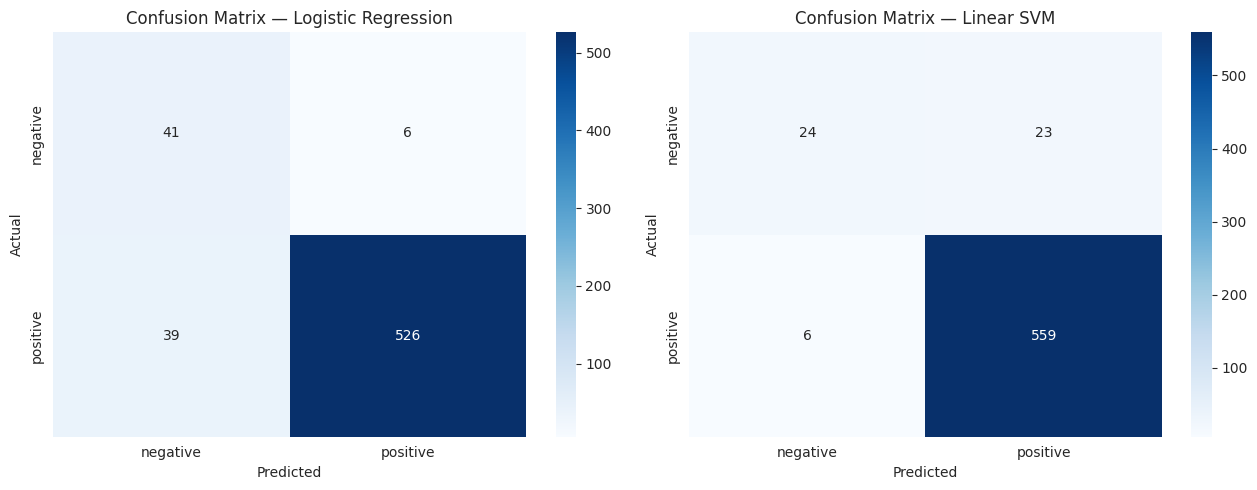

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, preds, title in zip(
    axes, [y_pred_lr, y_pred_svm], ["Logistic Regression", "Linear SVM"]
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["negative", "positive"],
                yticklabels=["negative", "positive"], ax=ax)
    ax.set_title(f"Confusion Matrix — {title}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("../model/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Model Comparison & Saving the Best Model

In [15]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Linear SVM"],
    "Accuracy": [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_svm)],
    "F1 Score (weighted)": [
        f1_score(y_test, y_pred_lr, average="weighted"),
        f1_score(y_test, y_pred_svm, average="weighted"),
    ],
    "F1 Score (negative class)": [
        f1_score(y_test, y_pred_lr, pos_label=0),
        f1_score(y_test, y_pred_svm, pos_label=0),
    ],
})
results


,Model,Accuracy,F1 Score (weighted),F1 Score (negative class)
0,Logistic Regression,0.926471,0.934918,0.645669
1,Linear SVM,0.952614,0.947735,0.623377


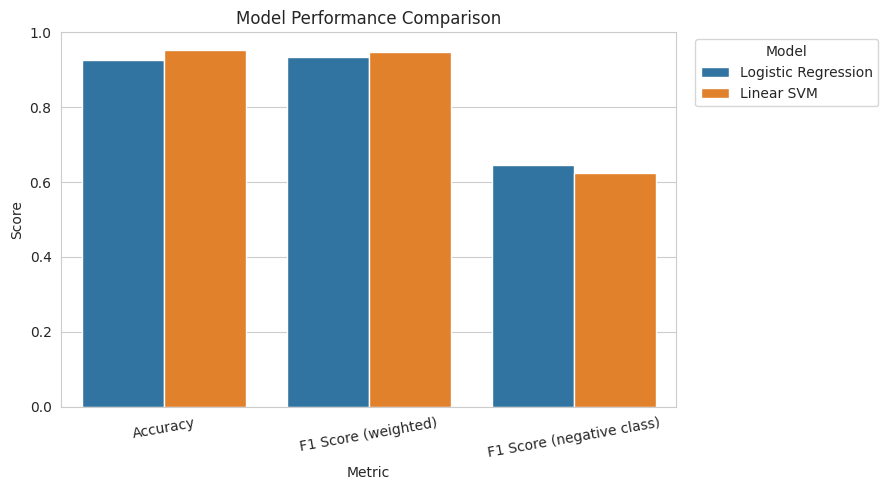

In [16]:
results_melt = results.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(9, 5))
sns.barplot(data=results_melt, x="Metric", y="Score", hue="Model")
plt.title("Model Performance Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=10)
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../model/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


In [17]:
# Pick the model with the higher weighted F1 score as the best model
best_idx = results["F1 Score (weighted)"].idxmax()
best_model_name = results.loc[best_idx, "Model"]
best_model = log_reg if best_model_name == "Logistic Regression" else svm_model
print("Best performing model:", best_model_name)

joblib.dump(best_model, "../model/sentiment_model.pkl")
joblib.dump(tfidf, "../model/tfidf_vectorizer.pkl")
print("Saved model and vectorizer to ../model/")


Best performing model: Linear SVM
Saved model and vectorizer to ../model/


## Summary

- Loaded and inspected the Amazon reviews dataset; found the classes imbalanced (majority positive).
- Cleaned review text (lowercasing, noise/URL/HTML removal, stopword removal).
- Generated word clouds for positive and negative reviews.
- Vectorized text with TF-IDF (unigrams + bigrams).
- Trained and evaluated two models — Logistic Regression and Linear SVM — using classification reports and confusion matrices.
- Compared both models on accuracy and F1 score, and saved the best-performing model and its vectorizer for use in the Part 2 Streamlit dashboard.